# Chapter 11
## Preprocessing data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import svd
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

### Replacing missing data

In [2]:
data = pd.DataFrame([[1, 2, np.nan],
                     [np.nan, 2, np.nan],
                     [3, np.nan, np.nan],
                     [np.nan, 3, 8],
                     [5, 3, np.nan]],
                    columns=['A', 'B', 'C'])
print(data,'\n')
print(data.isnull().sum(axis=0))

     A    B    C
0  1.0  2.0  NaN
1  NaN  2.0  NaN
2  3.0  NaN  NaN
3  NaN  3.0  8.0
4  5.0  3.0  NaN 

A    2
B    1
C    4
dtype: int64


In [3]:
data = data.drop('C', axis=1)
data['missing_B'] = data['B'].isnull().astype(int)
data['B'] = data['B'].fillna(data['B'].mean())
data['A'] = data['A'].interpolate(method='linear')

print(data)

     A    B  missing_B
0  1.0  2.0          0
1  2.0  2.0          0
2  3.0  2.5          1
3  4.0  3.0          0
4  5.0  3.0          0


### Singular value decomposition

In [4]:
A = np.arange(9).reshape(3, -1) + 1
print(A)

U, s, VT = svd(A)
Sigma = np.diag(s)
print("\nU:\n{}\n\nSigma:\n{}\n\nVt:\n{}".format(U, Sigma, VT))

B = U.dot(Sigma.dot(VT))
print("\n", B)

[[1 2 3]
 [4 5 6]
 [7 8 9]]

U:
[[-0.21483724  0.88723069  0.40824829]
 [-0.52058739  0.24964395 -0.81649658]
 [-0.82633754 -0.38794278  0.40824829]]

Sigma:
[[1.68481034e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.06836951e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.41842475e-16]]

Vt:
[[-0.47967118 -0.57236779 -0.66506441]
 [-0.77669099 -0.07568647  0.62531805]
 [-0.40824829  0.81649658 -0.40824829]]

 [[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]


In [5]:
import numpy as np

# 1. Calculate A.T @ A and find eigenvalues/vectors for V
eig_vals_V, eig_vecs_V = np.linalg.eigh(A.T @ A)

# 2. Calculate A @ A.T and find eigenvalues/vectors for U
eig_vals_U, eig_vecs_U = np.linalg.eigh(A @ A.T)

# 3. Sort eigenvalues and eigenvectors in descending order
idx_V = eig_vals_V.argsort()[::-1]
s_manual = np.sqrt(np.maximum(eig_vals_V[idx_V], 0)) # Ensure no negative due to precision
V_manual = eig_vecs_V[:, idx_V]

idx_U = eig_vals_U.argsort()[::-1]
U_manual = eig_vecs_U[:, idx_U]

# 4. Fix signs of U columns to satisfy A = U S V^T
# Since Av = su, we check the sign and adjust U if necessary
for i in range(len(s_manual)):
    if s_manual[i] > 1e-10: # Only for non-zero singular values
        # Check sign relative to the reconstruction
        if not np.allclose(A @ V_manual[:, i], s_manual[i] * U_manual[:, i]):
            U_manual[:, i] *= -1

Sigma_manual = np.diag(s_manual)
VT_manual = V_manual.T

print("Manual U:\n", U_manual)
print("\nManual Sigma:\n", Sigma_manual)
print("\nManual VT:\n", VT_manual)

# Verification
reconstructed = U_manual @ Sigma_manual @ VT_manual
print("\nReconstructed A:\n", reconstructed)

Manual U:
 [[-0.21483724  0.88723069 -0.40824829]
 [-0.52058739  0.24964395  0.81649658]
 [-0.82633754 -0.38794278 -0.40824829]]

Manual Sigma:
 [[1.68481034e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.06836951e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.84146317e-07]]

Manual VT:
 [[-0.47967118 -0.57236779 -0.66506441]
 [-0.77669099 -0.07568647  0.62531805]
 [ 0.40824829 -0.81649658  0.40824829]]

Reconstructed A:
 [[0.99999997 2.00000006 2.99999997]
 [4.00000006 4.99999988 6.00000006]
 [6.99999997 8.00000006 8.99999997]]


### Principal component analysis

In [6]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

# boston = load_boston()
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data_raw = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Define feature names and create DataFrame
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df_boston = pd.DataFrame(data_raw, columns=feature_names)


# Display the first few rows with headers
display(df_boston.head())





,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [7]:
# Check for missing values in raw_df
missing_values = raw_df.isnull().sum()
print("Missing values per column in raw_df:")
print(missing_values[missing_values > 0])

# Summary of total missing values
total_missing = raw_df.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing}")

Missing values per column in raw_df:
3     506
4     506
5     506
6     506
7     506
8     506
9     506
10    506
dtype: int64

Total missing values: 4048


In [8]:
# Verify that the processed df_boston has no missing values
print("Missing values in processed df_boston:")
print(df_boston.isnull().sum())

Missing values in processed df_boston:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
dtype: int64


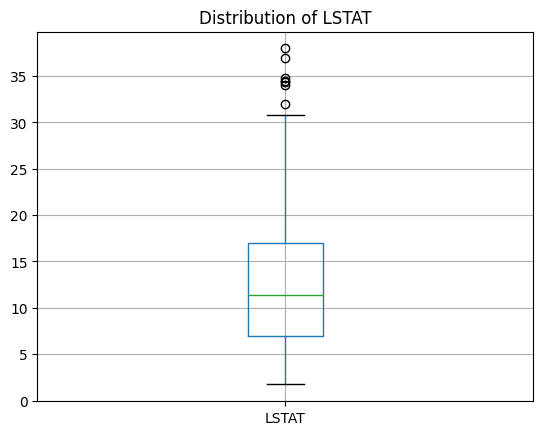

     LSTAT
0     4.98
1     9.14
2     4.03
3     2.94
4     5.33
..     ...
501   9.67
502   9.08
503   5.64
504   6.48
505   7.88

[506 rows x 1 columns]


In [9]:
# Fixed the indexing error to visualize the distribution of CRIM
df_boston[['LSTAT']].boxplot(return_type='axes')
plt.title('Distribution of LSTAT')
plt.show()

print(df_boston[['LSTAT']])


In [10]:
# Create a readable DataFrame for the variance summary
# Fit PCA on the DataFrame
pca = PCA().fit(df_boston)

variance_summary = pd.DataFrame(
    [pca.explained_variance_ratio_, np.cumsum(pca.explained_variance_ratio_)],
    columns=[f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    index=['Individual', 'Cumulative']
)

# Display the formatted table
display(variance_summary.round(3))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
Individual,0.806,0.163,0.021,0.007,0.001,0.001,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cumulative,0.806,0.969,0.990,0.997,0.998,0.999,1.0,1.0,1.0,1.0,1.0,1.0,1.0


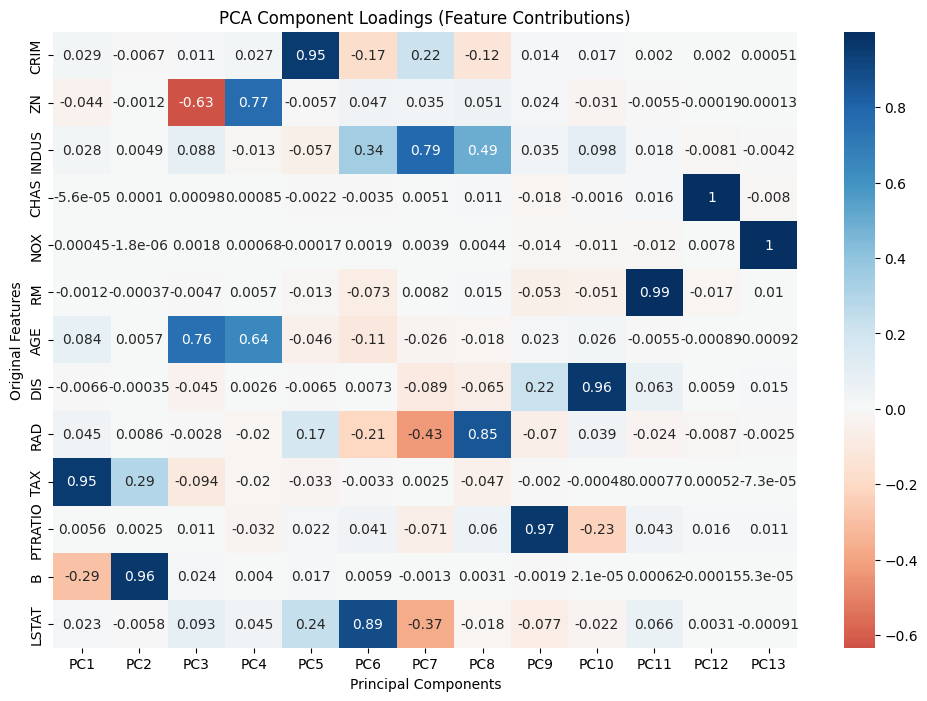

In [11]:
import seaborn as sns

# Create a DataFrame for the loadings (components_)
# pca.components_ has shape (n_components, n_features)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(feature_names))],
    index=feature_names
)

# Display the loadings heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title('PCA Component Loadings (Feature Contributions)')
plt.xlabel('Principal Components')
plt.ylabel('Original Features')
plt.show()

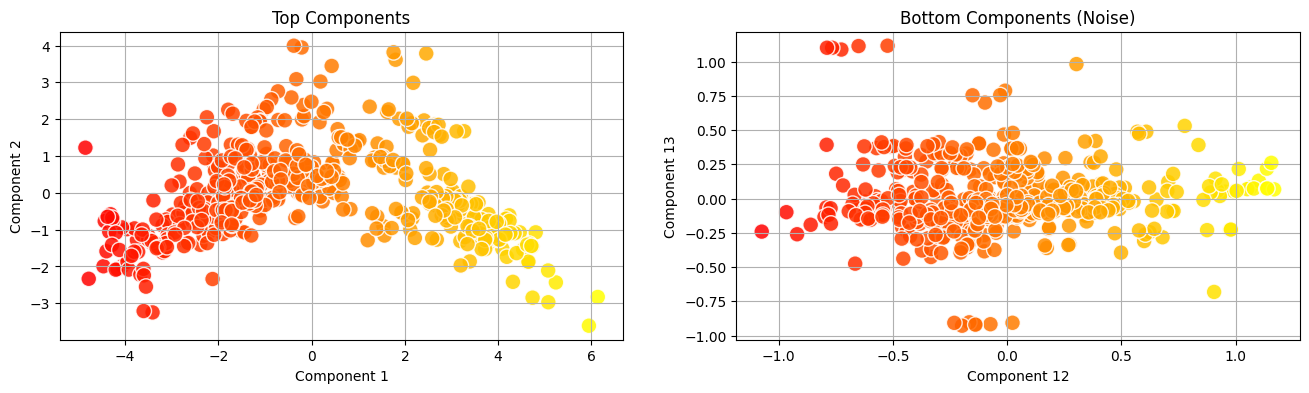

In [12]:
pca = PCA()
pca.fit(scale(df_boston))

C = pca.transform(scale(df_boston))

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
# Fixed: Added 'c' parameter to map colors to the first component
ax1.scatter(C[:,0], C[:,1], s=128, c=C[:,0], edgecolors='white', alpha=0.85, cmap='autumn')
ax1.grid()
ax1.set_title('Top Components')
ax1.set_xlabel('Component 1')
ax1.set_ylabel('Component 2')

# Fixed: Added 'c' parameter for the last components
ax2.scatter(C[:,-2], C[:,-1], s=128, c=C[:,-2], edgecolors='white', alpha=0.85, cmap='autumn')
ax2.grid()
ax2.set_title('Bottom Components (Noise)')
ax2.set_xlabel('Component 12')
ax2.set_ylabel('Component 13')

plt.show()



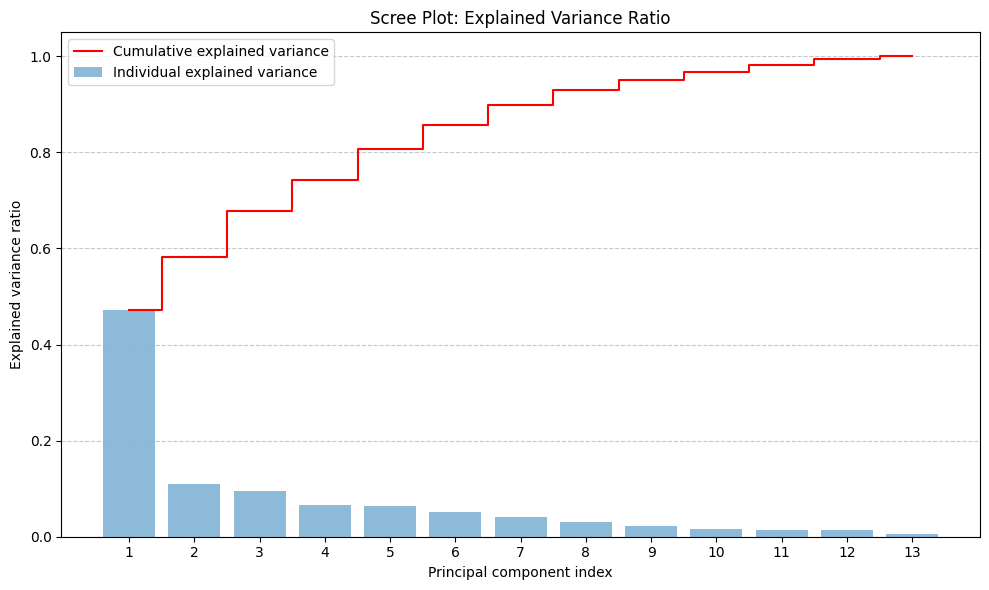

In [13]:
import matplotlib.pyplot as plt

# Data for the plot
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

# Create the visualization
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cum_sum_eigenvalues) + 1), cum_sum_eigenvalues, where='mid', label='Cumulative explained variance', color='red')

plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Scree Plot: Explained Variance Ratio')
plt.xticks(range(1, len(exp_var_pca) + 1))
plt.legend(loc='best')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpreting the Loadings

- **Magnitude**: Higher absolute values indicate a stronger contribution of that feature to the component.
- **Direction**: Positive and negative values show how the feature correlates with the principal component.
- **Dominant Features**: For example, if PC1 has high loadings for `TAX` and `RAD`, it suggests that PC1 primarily captures variance related to accessibility and property taxes in the Boston dataset.